# SNN FFT to Spike Train with snnTorch
End-to-end notebook.

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import snntorch as snn
from snntorch import spikegen
import matplotlib.pyplot as plt

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


## Load your data

In [3]:
# Replace with your own loading
# X: (N_samples, Nt, Nh)
# Y: (N_samples, Nt, C)
# X=np.load('X.npy')
# Y=np.load('Y.npy')

# Dummy data
N, Nt, Nh, C = 200, 100, 32, 8
X=np.random.rand(N,Nt,Nh).astype(np.float32)
Y=(np.random.rand(N,Nt,C)>0.9).astype(np.float32)


## Normalization

In [4]:
xmin=X.min(axis=(1,2),keepdims=True)
xmax=X.max(axis=(1,2),keepdims=True)
X=(X-xmin)/(xmax-xmin+1e-8)


## Dataset

In [5]:
class FFTDataset(Dataset):
    def __init__(self,X,Y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.Y=torch.tensor(Y,dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i],self.Y[i]

ds=FFTDataset(X,Y)
train_loader=DataLoader(ds,batch_size=16,shuffle=True)


## Encoder

In [6]:
ENCODER='current'  # current, rate, latency

def encode(x):
    if ENCODER=='current':
        return x
    if ENCODER=='rate':
        return spikegen.rate(x)
    if ENCODER=='latency':
        # returns (steps,batch,...); here use Nt encoding steps
        return spikegen.latency(x,num_steps=x.shape[1])


## Model

In [7]:
class SNNModel(nn.Module):
    def __init__(self,Nh,hidden,C):
        super().__init__()
        self.fc1=nn.Linear(Nh,hidden)
        self.lif1=snn.Leaky(beta=0.95)
        self.fc2=nn.Linear(hidden,C)
        self.lif2=snn.Leaky(beta=0.95)
    def forward(self,x):
        mem1=self.lif1.init_leaky()
        mem2=self.lif2.init_leaky()
        spks=[]
        for t in range(x.shape[1]):
            cur1=self.fc1(x[:,t])
            spk1,mem1=self.lif1(cur1,mem1)
            cur2=self.fc2(spk1)
            spk2,mem2=self.lif2(cur2,mem2)
            spks.append(spk2)
        return torch.stack(spks,1)

model=SNNModel(Nh,128,C).to(device)
opt=torch.optim.Adam(model.parameters(),lr=1e-3)
loss_fn=nn.BCELoss()


## Training

In [8]:
epochs=5
for ep in range(epochs):
    model.train()
    total=0
    for xb,yb in train_loader:
        xb,yb=xb.to(device), yb.to(device)
        if ENCODER!='current':
            xb=encode(xb)
            if ENCODER=='latency':
                xb=xb.permute(1,0,2,3).reshape(xb.shape[1],xb.shape[0],-1)
        pred=model(xb)
        loss=loss_fn(pred,yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total+=loss.item()
    print(ep,total/len(train_loader))


0 12.138221153846153
1 12.906850961538462
2 12.775841346153847
3 13.119591346153847
4 13.265024038461538


## Visualization

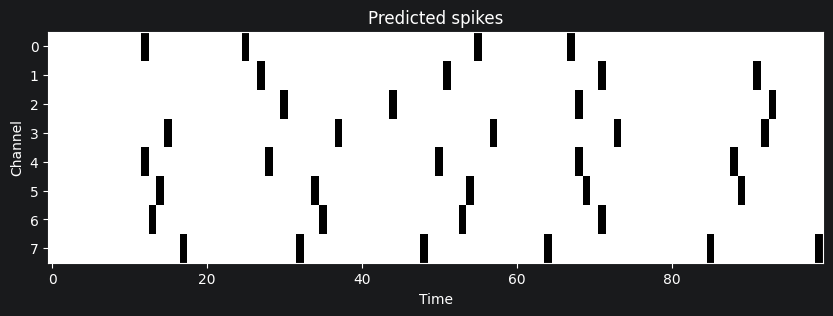

In [9]:
model.eval()
xb,yb=next(iter(train_loader))
with torch.no_grad():
    pred=model(xb.to(device)).cpu()
plt.figure(figsize=(10,3))
plt.imshow(pred[0].T,cmap='gray_r',aspect='auto')
plt.title('Predicted spikes')
plt.xlabel('Time')
plt.ylabel('Channel')
plt.show()
